<a href="https://colab.research.google.com/github/Srinivasan3009/srinivasan/blob/main/nm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python-headless pytesseract
!apt install tesseract-ocr -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [3]:
from google.colab import files
uploaded = files.upload()


Saving Datacluster_number_plates (79).jpg to Datacluster_number_plates (79).jpg


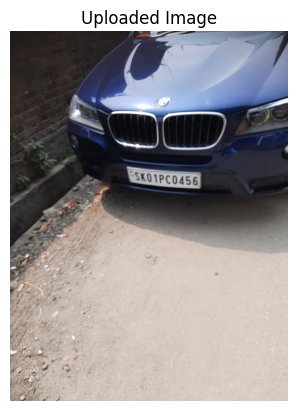

In [4]:
import cv2
from PIL import Image
import numpy as np
import pytesseract
from matplotlib import pyplot as plt

# Read the image
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()


Plate 1: 
Plate 2: Asko rPcousel


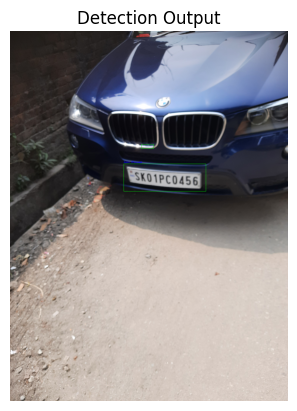

In [5]:
# Load cascade
cascade_path = cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
plate_cascade = cv2.CascadeClassifier(cascade_path)

def detect_and_recognize_plate(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    plates = plate_cascade.detectMultiScale(gray, 1.1, 5)
    results = []

    for (x, y, w, h) in plates:
        roi = image[y:y+h, x:x+w]
        text = pytesseract.image_to_string(roi, config='--psm 8')
        results.append((text.strip(), (x, y, w, h)))
        cv2.rectangle(image, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(image, text.strip(), (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,0,0), 2)

    return image, results

output_image, results = detect_and_recognize_plate(image.copy())

# Display results
for idx, (text, box) in enumerate(results):
    print(f"Plate {idx+1}: {text}")

plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Detection Output")
plt.show()
